In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


In [36]:
df = pd.read_csv('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/Compiled Output XGBoost.csv')

In [37]:
df['Date'] = pd.to_datetime(df['Date'])

start_date = '2025-10-01'
end_date = '2025-12-30'

df = df[df['Date'].between(start_date, end_date)]

In [38]:
df = df.drop(columns=['Date', 'Unnamed: 0'])

target_col = 'NDCI'

prediction_cols = [col for col in df.columns if col != target_col]

results_list = []

for pred_col in prediction_cols:
    
    df_clean = df[[target_col, pred_col]].dropna()
    
    y_true = df_clean[target_col]
    y_pred = df_clean[pred_col]
    
    if len(df_clean) == 0:
        print(f"Warning: No valid data found for pair {target_col} vs {pred_col}. Skipping.")
        continue
        
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    results_list.append({
        'Model/Prediction Column': pred_col,
        'R² Score': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })


In [39]:
results_df = pd.DataFrame(results_list)

#results_df = results_df.sort_values(by='R² Score', ascending=False).reset_index(drop=True)

In [40]:
print(results_df.to_string(index=False))

      Model/Prediction Column  R² Score   RMSE    MAE
 val12000_depth(7,Lr0.05,0.8)    0.8915 0.0162 0.0120
  val5100_depth(7,Lr0.03,0.8)    0.8914 0.0162 0.0120
  val3100_depth(7,Lr0.03,0.8)    0.8914 0.0163 0.0120
  val2100_depth(7,Lr0.03,0.8)    0.8913 0.0163 0.0120
   val500_depth(7,Lr0.05,0.8)    0.8900 0.0164 0.0119
  val1000_depth(7,Lr0.05,0.8)    0.8916 0.0162 0.0118
  val1000_depth(9,Lr0.05,0.8)    0.8960 0.0159 0.0114
  val2500_depth(9,Lr0.05,0.8)    0.8961 0.0159 0.0114
  val5000_depth(9,Lr0.05,0.8)    0.8961 0.0159 0.0114
 val25000_depth(9,Lr0.05,0.8)    0.8966 0.0159 0.0114
val120000_depth(9,Lr0.05,0.8)    0.8965 0.0159 0.0114
val120000_depth(9,Lr0.03,0.8)    0.8902 0.0163 0.0118


In [41]:
df_stat = df[['NDCI','val25000_depth(9,Lr0.05,0.8)']]

In [42]:
df_stat

,NDCI,"val25000_depth(9,Lr0.05,0.8)"
2100,0.10500,0.099935
2101,0.10150,0.100651
2102,0.09800,0.101220
2103,0.09450,0.114221
2104,0.09100,0.126044
...,...,...
2176,-0.06300,-0.028155
2177,-0.05412,-0.044194
2178,-0.04525,-0.044949
2179,-0.03637,-0.043081


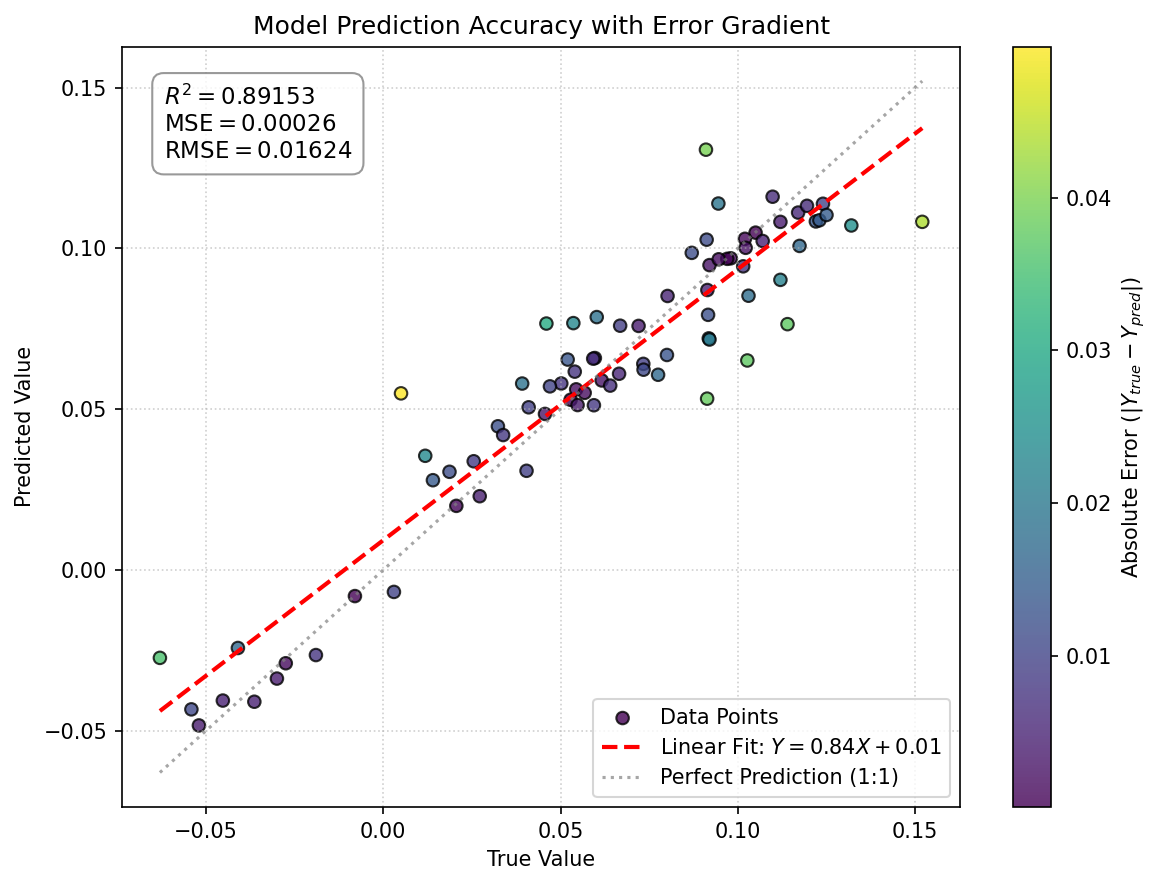

In [43]:
true_values = df_stat.iloc[:, 0]       
predicted_values = df.iloc[:, 1]  

absolute_errors = np.abs(true_values - predicted_values)
mse = mean_squared_error(true_values, predicted_values)
rmse = np.sqrt(mse)
r2 = r2_score(true_values, predicted_values)

slope, intercept = np.polyfit(true_values, predicted_values, 1)
x_fit = np.linspace(min(true_values), max(true_values), 100)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

sc = ax.scatter(true_values, predicted_values, c=absolute_errors, cmap='viridis', 
                edgecolors='k', alpha=0.8, label='Data Points')

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Absolute Error ($|Y_{true} - Y_{pred}|$)')

ax.plot(x_fit, y_fit, color='red', linestyle='--', linewidth=2, 
        label=f'Linear Fit: $Y = {slope:.2f}X + {intercept:.2f}$')

ax.plot([min(true_values), max(true_values)], [min(true_values), max(true_values)], 
        color='gray', linestyle=':', alpha=0.7, label='Perfect Prediction (1:1)')

ax.set_xlabel('True Value')
ax.set_ylabel('Predicted Value')
ax.set_title('Model Prediction Accuracy with Error Gradient')

stats_text = (
    f'$R^2 = {r2:.5f}$\n'
    f'$\\mathrm{{MSE}} = {mse:.5f}$\n'
    f'$\\mathrm{{RMSE}} = {rmse:.5f}$'
)

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

plt.savefig('XGBoost Model Performance.pdf')
plt.show()
